In [12]:
%matplotlib inline

import jax.numpy as jnp
from jax import value_and_grad
from jax import random
from scipy.optimize import minimize
from dataclasses import dataclass
import matplotlib.pyplot as plt
import seaborn as snb

from mpl_toolkits.axes_grid1 import make_axes_locatable

def add_colorbar(im, fig, ax):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes('right', size='5%', pad=0.05)
    fig.colorbar(im, cax=cax, orientation='vertical')

# we want to use 64 bit floating precision
import jax
jax.config.update("jax_enable_x64", True)

# for plotting
snb.set_style('darkgrid')
snb.set_theme(font_scale=1.25)

In [13]:
def generate_samples(key, m, K, num_samples, jitter: float=0):
    """ returns M samples from an Gaussian process with mean m and kernel matrix K. The function generates num_samples of z ~ N(0, I) and transforms them into f  ~ N(m, K) via the Cholesky factorization.

    
    arguments:
        key              -- jax random key for controlling the random number generator
        m                -- mean vector (shape (N,))
        K                -- kernel matrix (shape NxN)
        num_samples      -- number of samples to generate (positive integer)
        jitter           -- amount of jitter (non-negative scalar)
    
    returns 
        f_samples        -- a numpy matrix containing the samples of f (shape N x num_samples)
    """

    # generate samples from N(0, 1) of shape (N, num_samples)
    zs = random.normal(key, shape=(len(K), num_samples))
    L = jnp.linalg.cholesky(K + jnp.eye(len(K))*jitter)
    f_samples = L @ zs + m[:, None] 

    # sanity check of dimensions
    assert f_samples.shape == (len(K), num_samples), f"The shape of f_samples appears wrong. Expected shape ({len(K)}, {num_samples}), but the actual shape was {f_samples.shape}. Please check your code. "
    return f_samples


# sanity check of implementation
key = random.PRNGKey(1)
num_samples = 100000
m = jnp.array([jnp.pi, jnp.sqrt(2)])
V = jnp.array([[0.123, -0.05], [-0.05, 0.123]])
f_samples = generate_samples(key, m, V, num_samples)
assert jnp.linalg.norm(jnp.mean(f_samples, 1)- m) < 1e-2, "The mean of f_samples appears wrong. Please check your code"
assert jnp.linalg.norm(jnp.cov(f_samples) - V) < 1e-2, "The covariance of f_samples appears wrong. Please check your code"
print('Everything seems ok.')

Everything seems ok.


In [14]:
@dataclass
class Hyperparameters(object):
    kappa0:         float = 1.0
    kappa1:         float = 1.0
    kappa2:         float = 1.0
    lengthscale:    float = 0.5 # characteristic lengthscale, positive scalar (default=0.5)
    sigma:          float = 0.0 # noise std. dev., positive scalar (default=0)

    def to_array(self):
        """ return hyperparameters as flat JaX-array (to be used later) """
        return jnp.array([self.kappa0, self.kappa1, self.kappa2, self.lengthscale, self.sigma])
        
    @staticmethod
    def from_array(hyper_array):
        """ instantiates Hyperparameter object from flat JaX-array (or list) of hyperparameters (to be used later) """
        kappa0, kappa1, kappa2, lengthscale, sigma = hyper_array
        return Hyperparameters(kappa0, kappa1, kappa2, lengthscale, sigma)
    
    def __repr__(self):
        """ for reporting hyperparameter values """
        return f'Hyperparameters(kappas={self.kappa0:3.2f}, {self.kappa1:3.2f}, {self.kappa2:3.2f}, lengthscale={self.lengthscale:3.2f}, sigma={self.sigma:3.2f})'

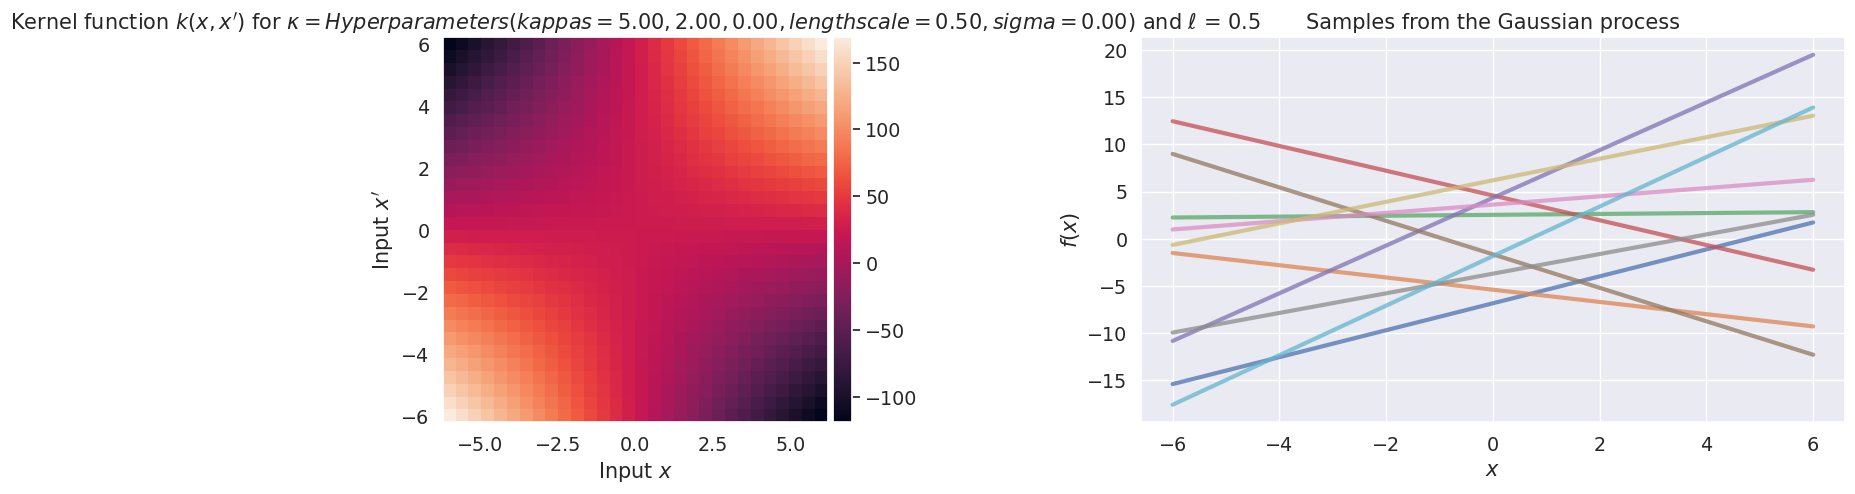

In [20]:
class StationaryIsotropicKernel(object):

    def __init__(self, kernel_fun):
        """
            the argument kernel_fun must be a function of two arguments kernel_fun(||tau||, hyperparameters), e.g. 
            squared_exponential = lambda tau, hyper: hyper.kappa**2*np.exp(-0.5*tau**2/hyper.lengthscale**2).
        """
        self.kernel_fun = kernel_fun

    def construct_kernel(self, X1, X2, hyperparameters, jitter=1e-8):
        """ compute and returns the NxM kernel matrix between the two sets of input X1 (shape NxD) and X2 (MxD) using the stationary and isotropic covariance function specified by self.kernel_fun
    
        arguments:
            X1              -- NxD matrix
            X2              -- MxD matrix or None
            hyperparameters -- Hyperparameter object compatible with self.kernel_fun function
            jitter          -- non-negative scalar
        
        returns
            K               -- NxM matrix    
        """

        # extract dimensions 
        N, M = X1.shape[0], X2.shape[0]
        K = X1[:,jnp.newaxis,:] - X2[jnp.newaxis,:,:]
        # Shape (N, D, M)
        K = jnp.linalg.norm(K, axis=-1)
        K = self.kernel_fun(K, hyperparameters) + jnp.eye(N,M)*jitter
        assert K.shape == (N, M), f"The shape of K appears wrong. Expected shape ({N}, {M}), but the actual shape was {K.shape}. Please check your code. "
        return K

# In this exercise our kernal is not isotropic.
class LinearKernel(object):

    def __init__(self, kernel_fun):
        self.kernel_fun = kernel_fun

    def construct_kernel(self, X1, X2, hyperparameters, jitter=1e-8):
        # extract dimensions 
        N, M = X1.shape[0], X2.shape[0]
        K = X1 @ X2.T + jnp.eye(N,M)*jitter
        K = self.kernel_fun(K, hyperparameters) 
        assert K.shape == (N, M), f"The shape of K appears wrong. Expected shape ({N}, {M}), but the actual shape was {K.shape}. Please check your code. "
        return K

def squared_exponential(tau, hyperparameters):
    return hyperparameters.kappa2**2*jnp.exp(-0.5*tau**2/hyperparameters.lengthscale**2)

def linear(K, hyperparameters):
    return hyperparameters.kappa1**2*K
        
# create an Nx1 vector of equidistant points in [-6, 6]
N = 30
X = jnp.linspace(-6, 6, N)[:, None]

# number of samples to be plotted
num_samples = 10

# specify random seed
key = random.PRNGKey(1)

# specify hyperparameters
hyper = Hyperparameters(kappa0=5, kappa1=2, kappa2=0, lengthscale=0.5)

# instantiate kernel object and construct kernel
kernel1 = StationaryIsotropicKernel(squared_exponential)
kernel2 = LinearKernel(linear)

K = kernel1.construct_kernel(X, X, hyper) + kernel2.construct_kernel(X, X, hyper) + hyper.kappa0**2

# plot
fig, ax = plt.subplots(1, 2, figsize=(20, 5))

im = ax[0].pcolormesh(X.flatten(), X.flatten(), K, shading='auto')
ax[0].set(xlabel='Input $x$', ylabel="Input $x'$", title=f"Kernel function $k(x, x')$ for $\\kappa = {hyper.__repr__()}$ and $\\ell$ = {hyper.lengthscale:2.1f}")
ax[0].grid(False)
ax[0].set_aspect('equal')
add_colorbar(im, fig, ax[0])

m = jnp.zeros(len(X))
f_samples = generate_samples(key, m, K, num_samples=num_samples, jitter=1e-8)
ax[1].plot(X, f_samples, alpha=0.75, linewidth=3);
ax[1].grid(True)
ax[1].set(xlabel='$x$', ylabel='$f(x)$', title='Samples from the Gaussian process');
plt.savefig("gp7_1.png")


# Part 2